<a href="https://colab.research.google.com/github/fajarrinaldi88/Data-Science-2026/blob/main/Pertemuan10_FajarRinaldi_250401020204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Nama : Fajar Rinaldi
* NIM : 250401020204
* Kelas : IF405


```
#Pertemuan 10:
```
**Algoritma Klasifikasi (Bagian 2)**

Metode Ensemble (Random Forest) dan penanganan Imbalanced Dataset.

**Muat dan Eksplorasi Data**

In [8]:
import pandas as pd
df = pd.read_csv("https://github.com/fajarrinaldi88/Data-Science-2026/raw/refs/heads/main/telco_churn.csv")
print(df.shape)
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


**Preprocessing**

In [9]:
from sklearn.model_selection import train_test_split

data_prep = df.drop('customerID', axis=1)

data_prep['TotalCharges'] = pd.to_numeric(data_prep['TotalCharges'], errors='coerce')
data_prep = data_prep.fillna(0)

df_encoded = pd.get_dummies(data_prep, drop_first=True)

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Ukuran X_tr: {X_tr.shape}")
print(f"Ukuran X_te: {X_te.shape}")

Ukuran X_tr: (5634, 30)
Ukuran X_te: (1409, 30)


**Latih Model, Evaluasi, dan Prediksi**

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

print("Model telah selesai dilatih")

Model telah selesai dilatih


**Evaluasi**

In [11]:
y_pred = rf.predict(X_te)
y_prob = rf.predict_proba(X_te)[:, 1]

print("Classification Report:")
print(classification_report(y_te, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_te, y_prob):.4f}")


Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1035
        True       0.63      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8260


**Ringkasan Metrik Evaluasi**

Berikut adalah ringkasan metrik utama untuk mengevaluasi performa model dalam mendeteksi churn:

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_te, y_pred)
precision = precision_score(y_te, y_pred)
recall = recall_score(y_te, y_pred)
f1 = f1_score(y_te, y_pred)

metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

display(metrics_summary.style.format({'Score': '{:.4f}'}))


,Metric,Score
0,Accuracy,0.7899
1,Precision,0.6336
2,Recall,0.4947
3,F1-Score,0.5556


#### Interpretasi metrik evaluasi

*   **Accuracy (0.7899):** Model benar dalam memprediksi sekitar 79% data secara keseluruhan, namun akurasi saja tidak cukup untuk data yang tidak seimbang.
*   **Precision (0.6336):** Sekitar 63% dari pelanggan yang diprediksi churn memang benar-benar churn, penting untuk efisiensi promosi.
*   **Recall (0.4947):** Model berhasil mengidentifikasi 49% dari total pelanggan yang sebenarnya churn, menunjukkan adanya *false negative*.
*   **F1-Score (0.5556):** Memberikan keseimbangan antara Precision dan Recall, menjadi acuan utama karena data cenderung tidak seimbang.

Dalam kasus Customer Churn yang *imbalanced* (jumlah *non-churn* > *churn*):

*   **Accuracy:** Seringkali menyesatkan karena dapat tinggi meskipun model gagal mendeteksi pelanggan berisiko.
*   **Recall (Sensitivity):** Sangat penting untuk meminimalkan *False Negative* (pelanggan yang churn tapi diprediksi bertahan), karena kehilangan pelanggan lebih mahal.
*   **F1-Score:** Metrik terbaik untuk perbandingan objektif karena menyeimbangkan *Precision* dan *Recall* pada data tidak seimbang.
*   **Precision:** Penting untuk efisiensi biaya insentif, memastikan target tepat sasaran.

**Confusion Matrix**

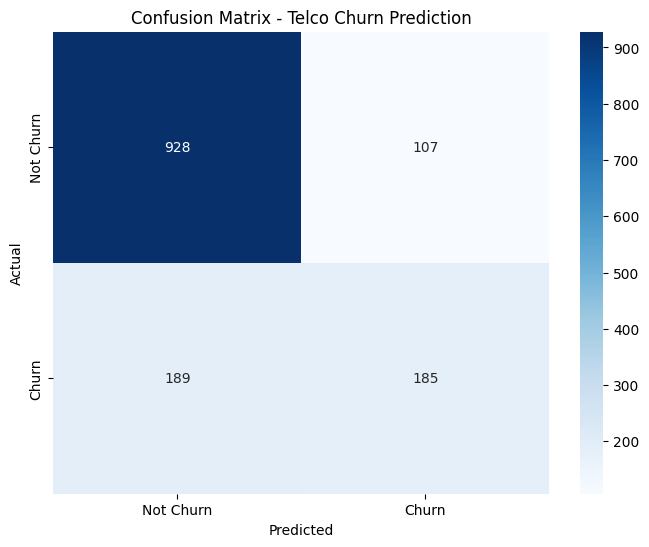

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Telco Churn Prediction')
plt.show()

**Prediksi Probabilitas**

Menampilkan 5 prediksi probabilitas churn teratas

In [14]:
prob_df = pd.DataFrame({'Actual': y_te, 'Churn_Probability': y_prob})
print("\nContoh Prediksi Probabilitas Churn:")
print(prob_df.head())


Contoh Prediksi Probabilitas Churn:
      Actual  Churn_Probability
437    False           0.000000
2280   False           0.810000
2235   False           0.076667
4460   False           0.250000
3761   False           0.003333


## Kesimpulan Akhir

### 1. Performa Model
*   **Random Forest menunjukkan kemampuan baik** dalam membedakan churn (ROC-AUC 0.826).
*   **Akurasi 79%** kurang informatif untuk data tidak seimbang.

### 2. Metrik Kritis (untuk data tidak seimbang)
*   **Recall (0.495)**: Model **masih melewatkan hampir 50% pelanggan yang akan churn** (tinggi *False Negative*). Ini kerugian besar bagi bisnis.
*   **Precision (0.634)**: Sekitar 63% prediksi churn benar, menunjukkan efisiensi sedang dalam penargetan.
*   **F1-Score (0.556)**: Metrik terbaik yang menyeimbangkan Precision dan Recall, mengindikasikan **perlu peningkatan signifikan**.

### 3. Pentingnya `class_weight='balanced'`
*   Penggunaan `class_weight='balanced'` sangat krusial agar model tidak bias pada kelas mayoritas (*non-churn*).

### 4. Keterbatasan
*   **Keterbatasan**: Tingkat *False Negative* yang tinggi adalah masalah utama.
